# **AI/ML Explore 3 - Real-Time Tracking with YOLOv26**

What is YOLO, and why we using v26

What is COCO

How YOLO connect to CNN

### **YOLO (You Only Look Once**)

***YOLO*** -  a popular object detection and image segmentation model, was developed by Joseph Redmon and Ali Farhadi at the University of Washington. Launched in 2015, YOLO gained popularity for its high speed and accuracy.


*    The name refers to how it works — it looks at an image once (in a single pass) to detect all objects, rather than scanning the image multiple times.


<img src="https://static.wixstatic.com/media/4c4fd6_b37a79ddf4624573a8f137b7a46772a5~mv2.jpg/v1/fill/w_1332,h_568,al_c,q_85/4c4fd6_b37a79ddf4624573a8f137b7a46772a5~mv2.jpg" width="700">

*What does it do?*

Given an image, YOLO outputs:


*   Bouding Boxes - where objects are located
*   Class Labels - what each object is (person, ball, car, etc)
*   Confidence Scores - how sure the model is

<img src="https://i0.wp.com/ubiai.tools/wp-content/uploads/2023/10/YOLO.jpg?fit=1200%2C600&ssl=1" width="700">



Check to see if we have access to the GPU

If not, navigate to

*   Runtime
*   Change Runtime Type
*   Select GPU (L4 or T4)



In [ ]:
!nvidia-smi

Sun Mar  1 01:54:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   64C    P0             32W /   72W |   19090MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Set up base directory path
import os
HOME = os.getcwd()
print(HOME)

/content


### **Install Dependencies**

*Ultralytics* - train the model

*Roboflow* - download the dataset and deploy the fine-tuned model

In [ ]:
!pip install -q ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 97.1 MB/s eta 0:00:00


### **Download Football Player Dataset**



In [ ]:
# Create the folder only if it doesn't exist
datasets_path = f"{HOME}/datasets"
os.makedirs(datasets_path, exist_ok=True)
os.chdir(datasets_path)

In [ ]:
from roboflow import Roboflow
from google.colab import userdata
from IPython.display import Image # display image

# Retrieve Roboflow API Key from secret
ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')

# Initialize connection to Roboflow using your API key
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# Access a specific workspace and project on Roboflow
# Workspace: "roboflow-jvuqo" (the account/team name)
# Project: "football-players-detection-3zvbc" (the dataset project)
project = rf.workspace("roboflow-jvuqo").project("football-players-detection-3zvbc")
version = project.version(20) # select version 20 of the dataset
dataset = version.download("yolo26") # download the dataset in YOLO26 format to the current directory


loading Roboflow workspace...
loading Roboflow project...


### **Custom Training**

In [ ]:
'''THE LOSS EXPLANATION'''

In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Load the YOLO26 extra-large model with pretrained weights (trained on COCO dataset)
model = YOLO("yolo26x.pt")

# Store training metrics and metadata
results = model.train(
    data=f"{dataset.location}/data.yaml", # path to the data.yaml config file
    batch=6, # number of images processed at once
    epochs=50, # number of complete passes through the entire dataset
    imgsz=1280, # resize all images to 1280x1280 pixels
    plots=True # generate training plots (loss curves, confusion matrix, PR curves, etc.)
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/football-players-detection-20/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

In [ ]:
# look into training result

/content


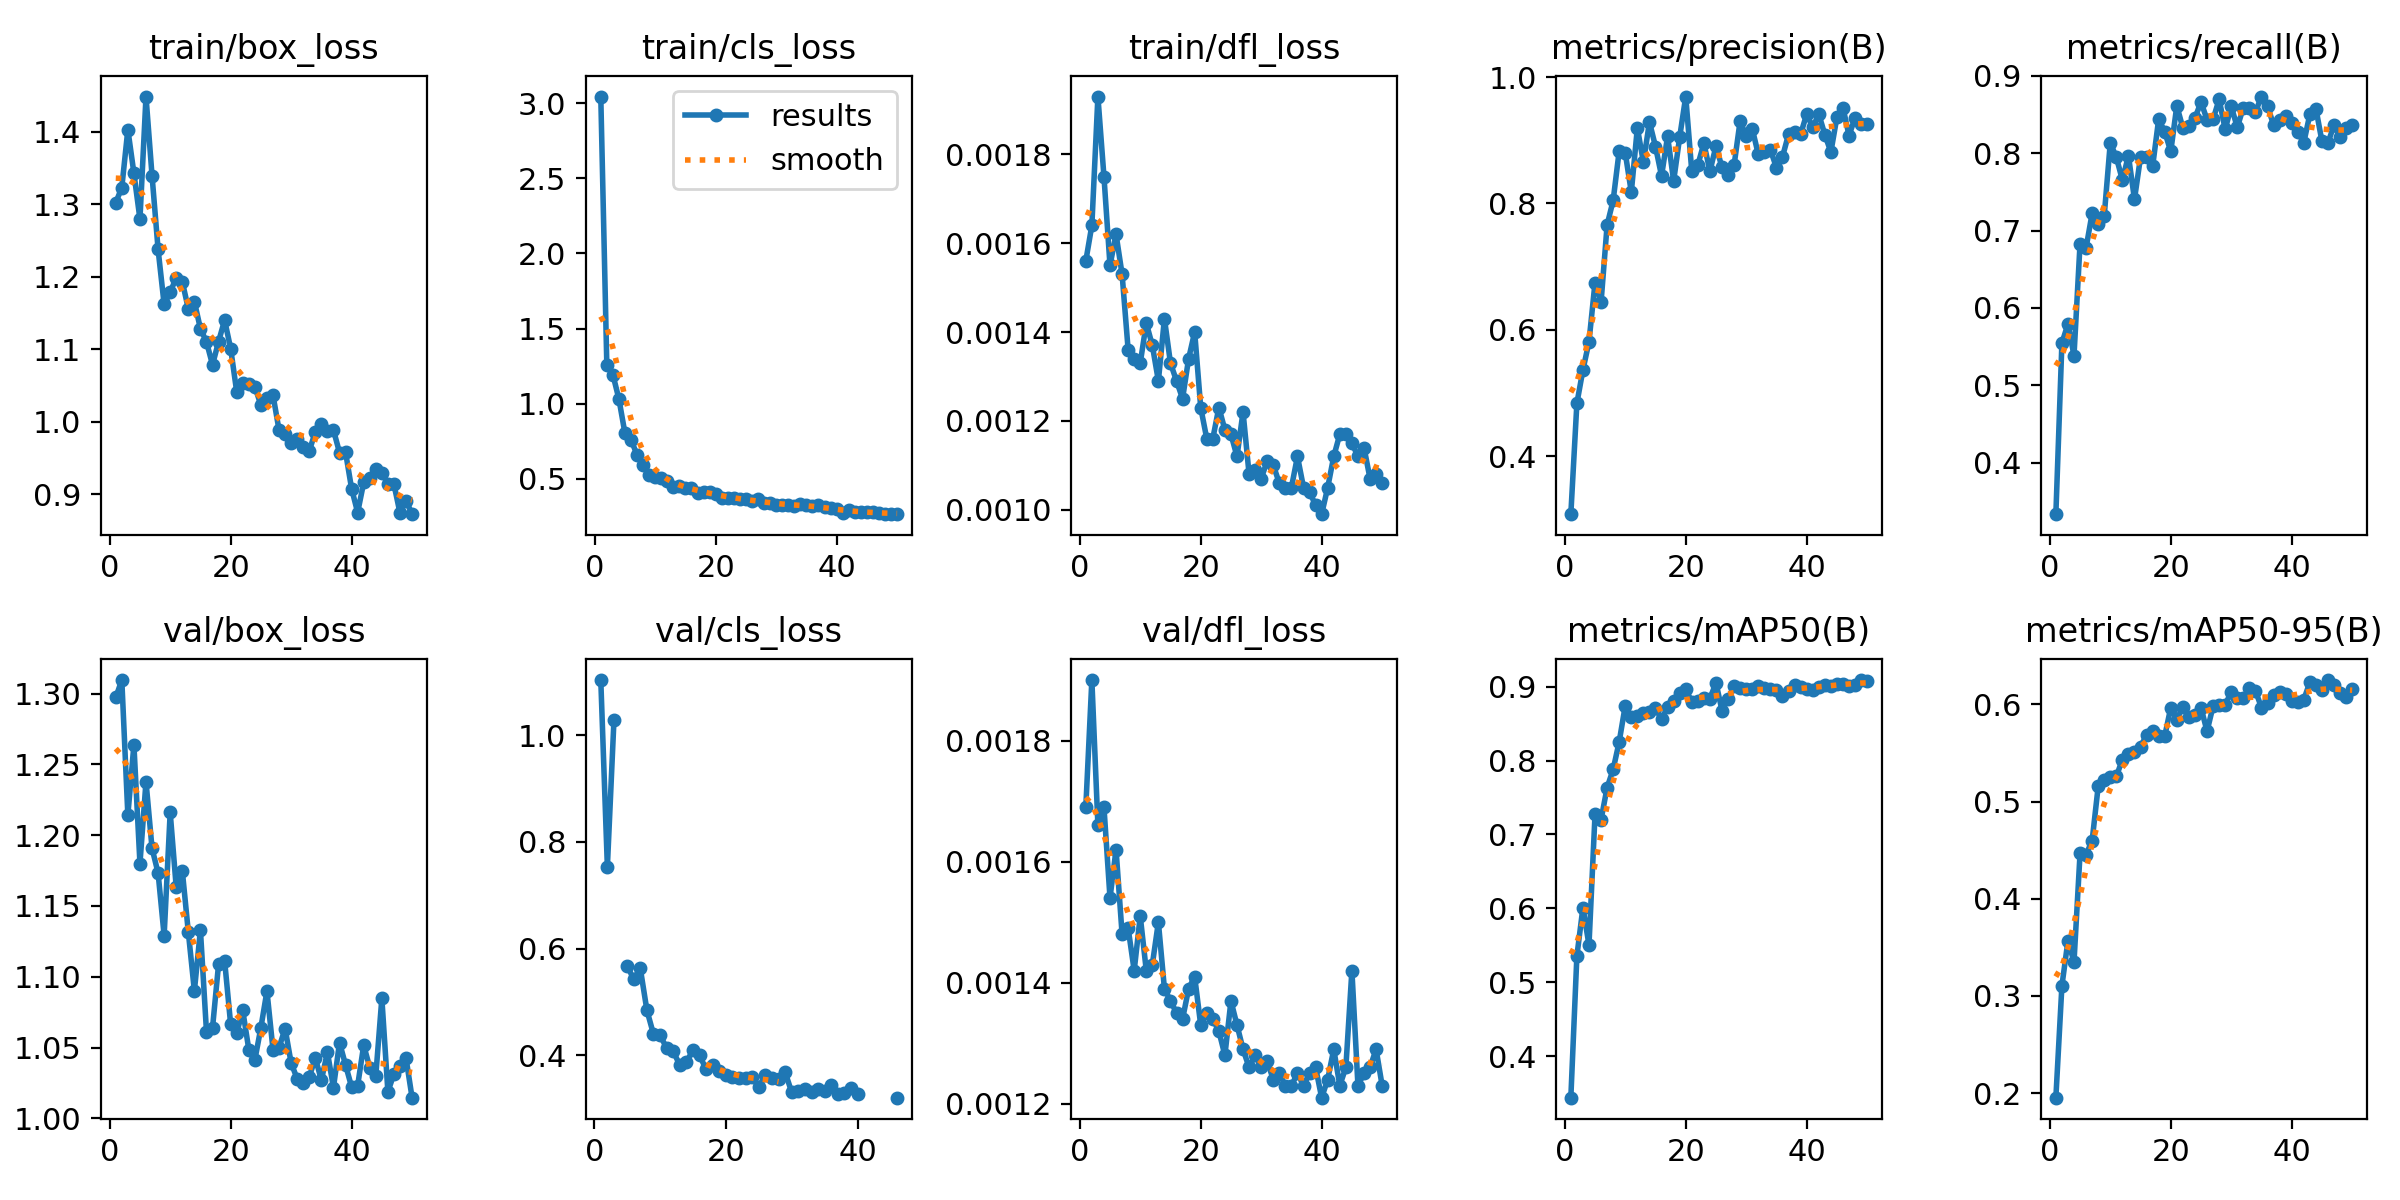

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/results.png', width=600)

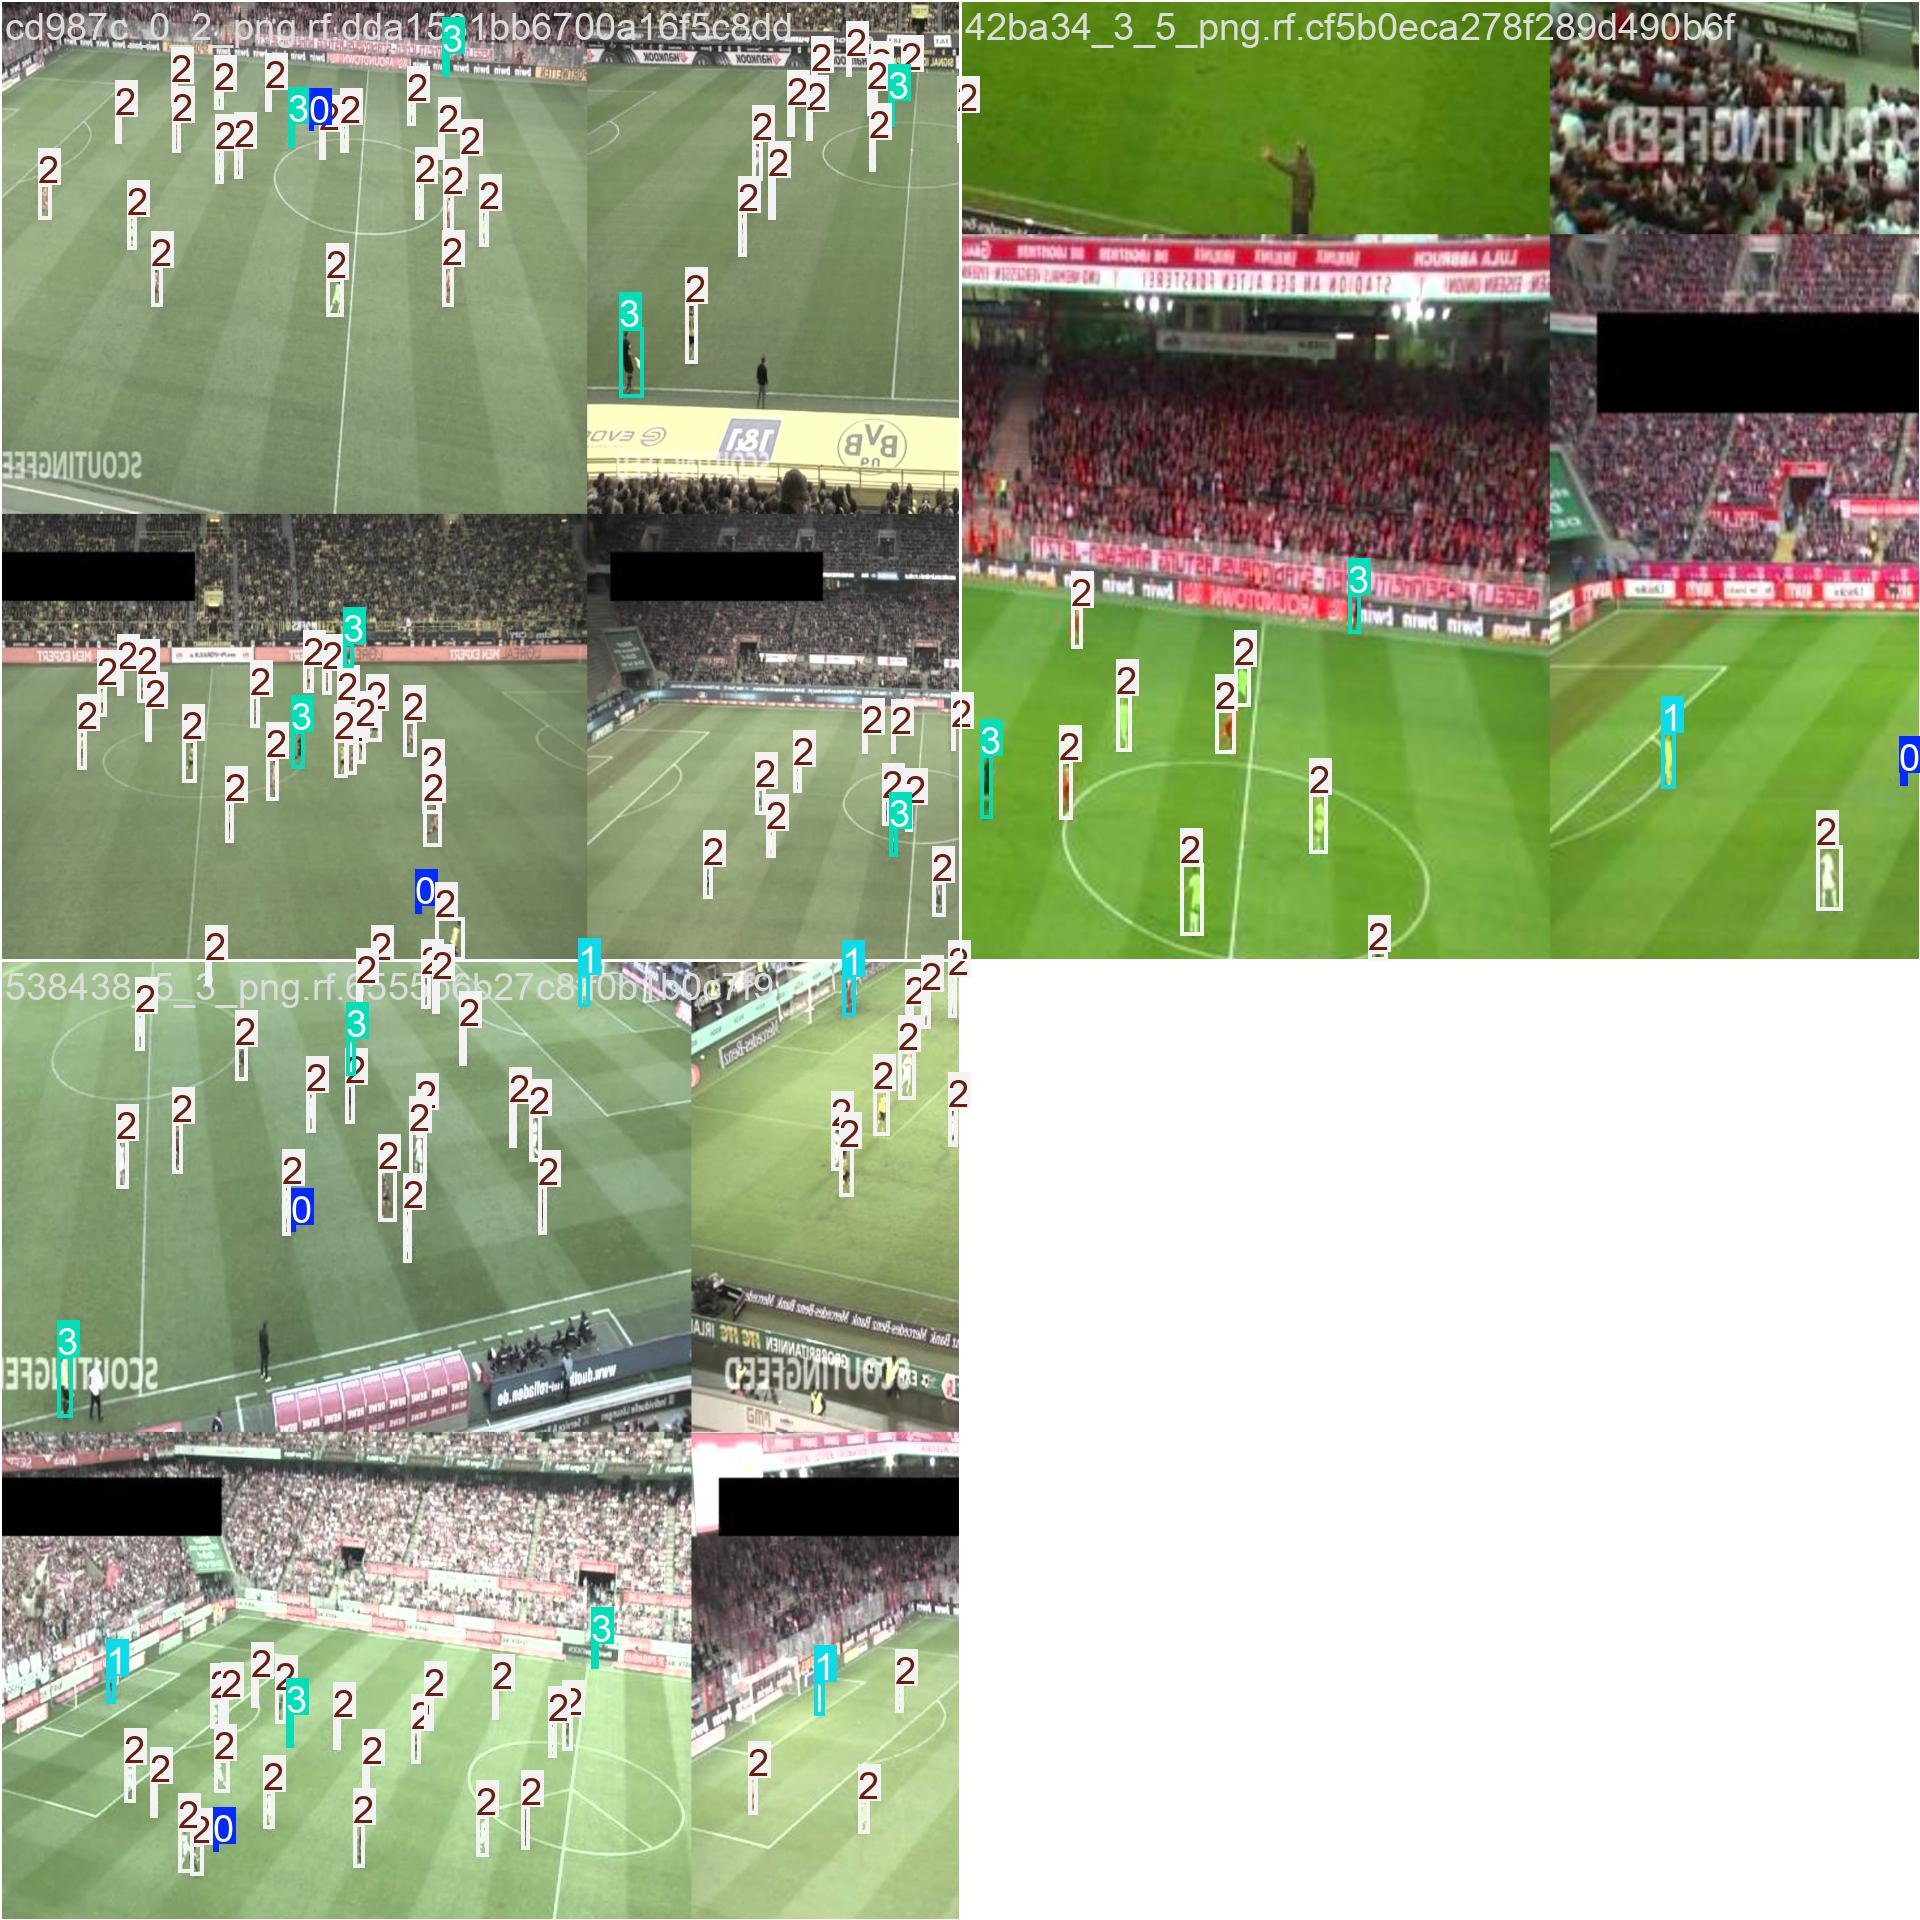

In [ ]:
Image(filename=f'{HOME}/runs/detect/train/train_batch2001.jpg', width=600)

/content


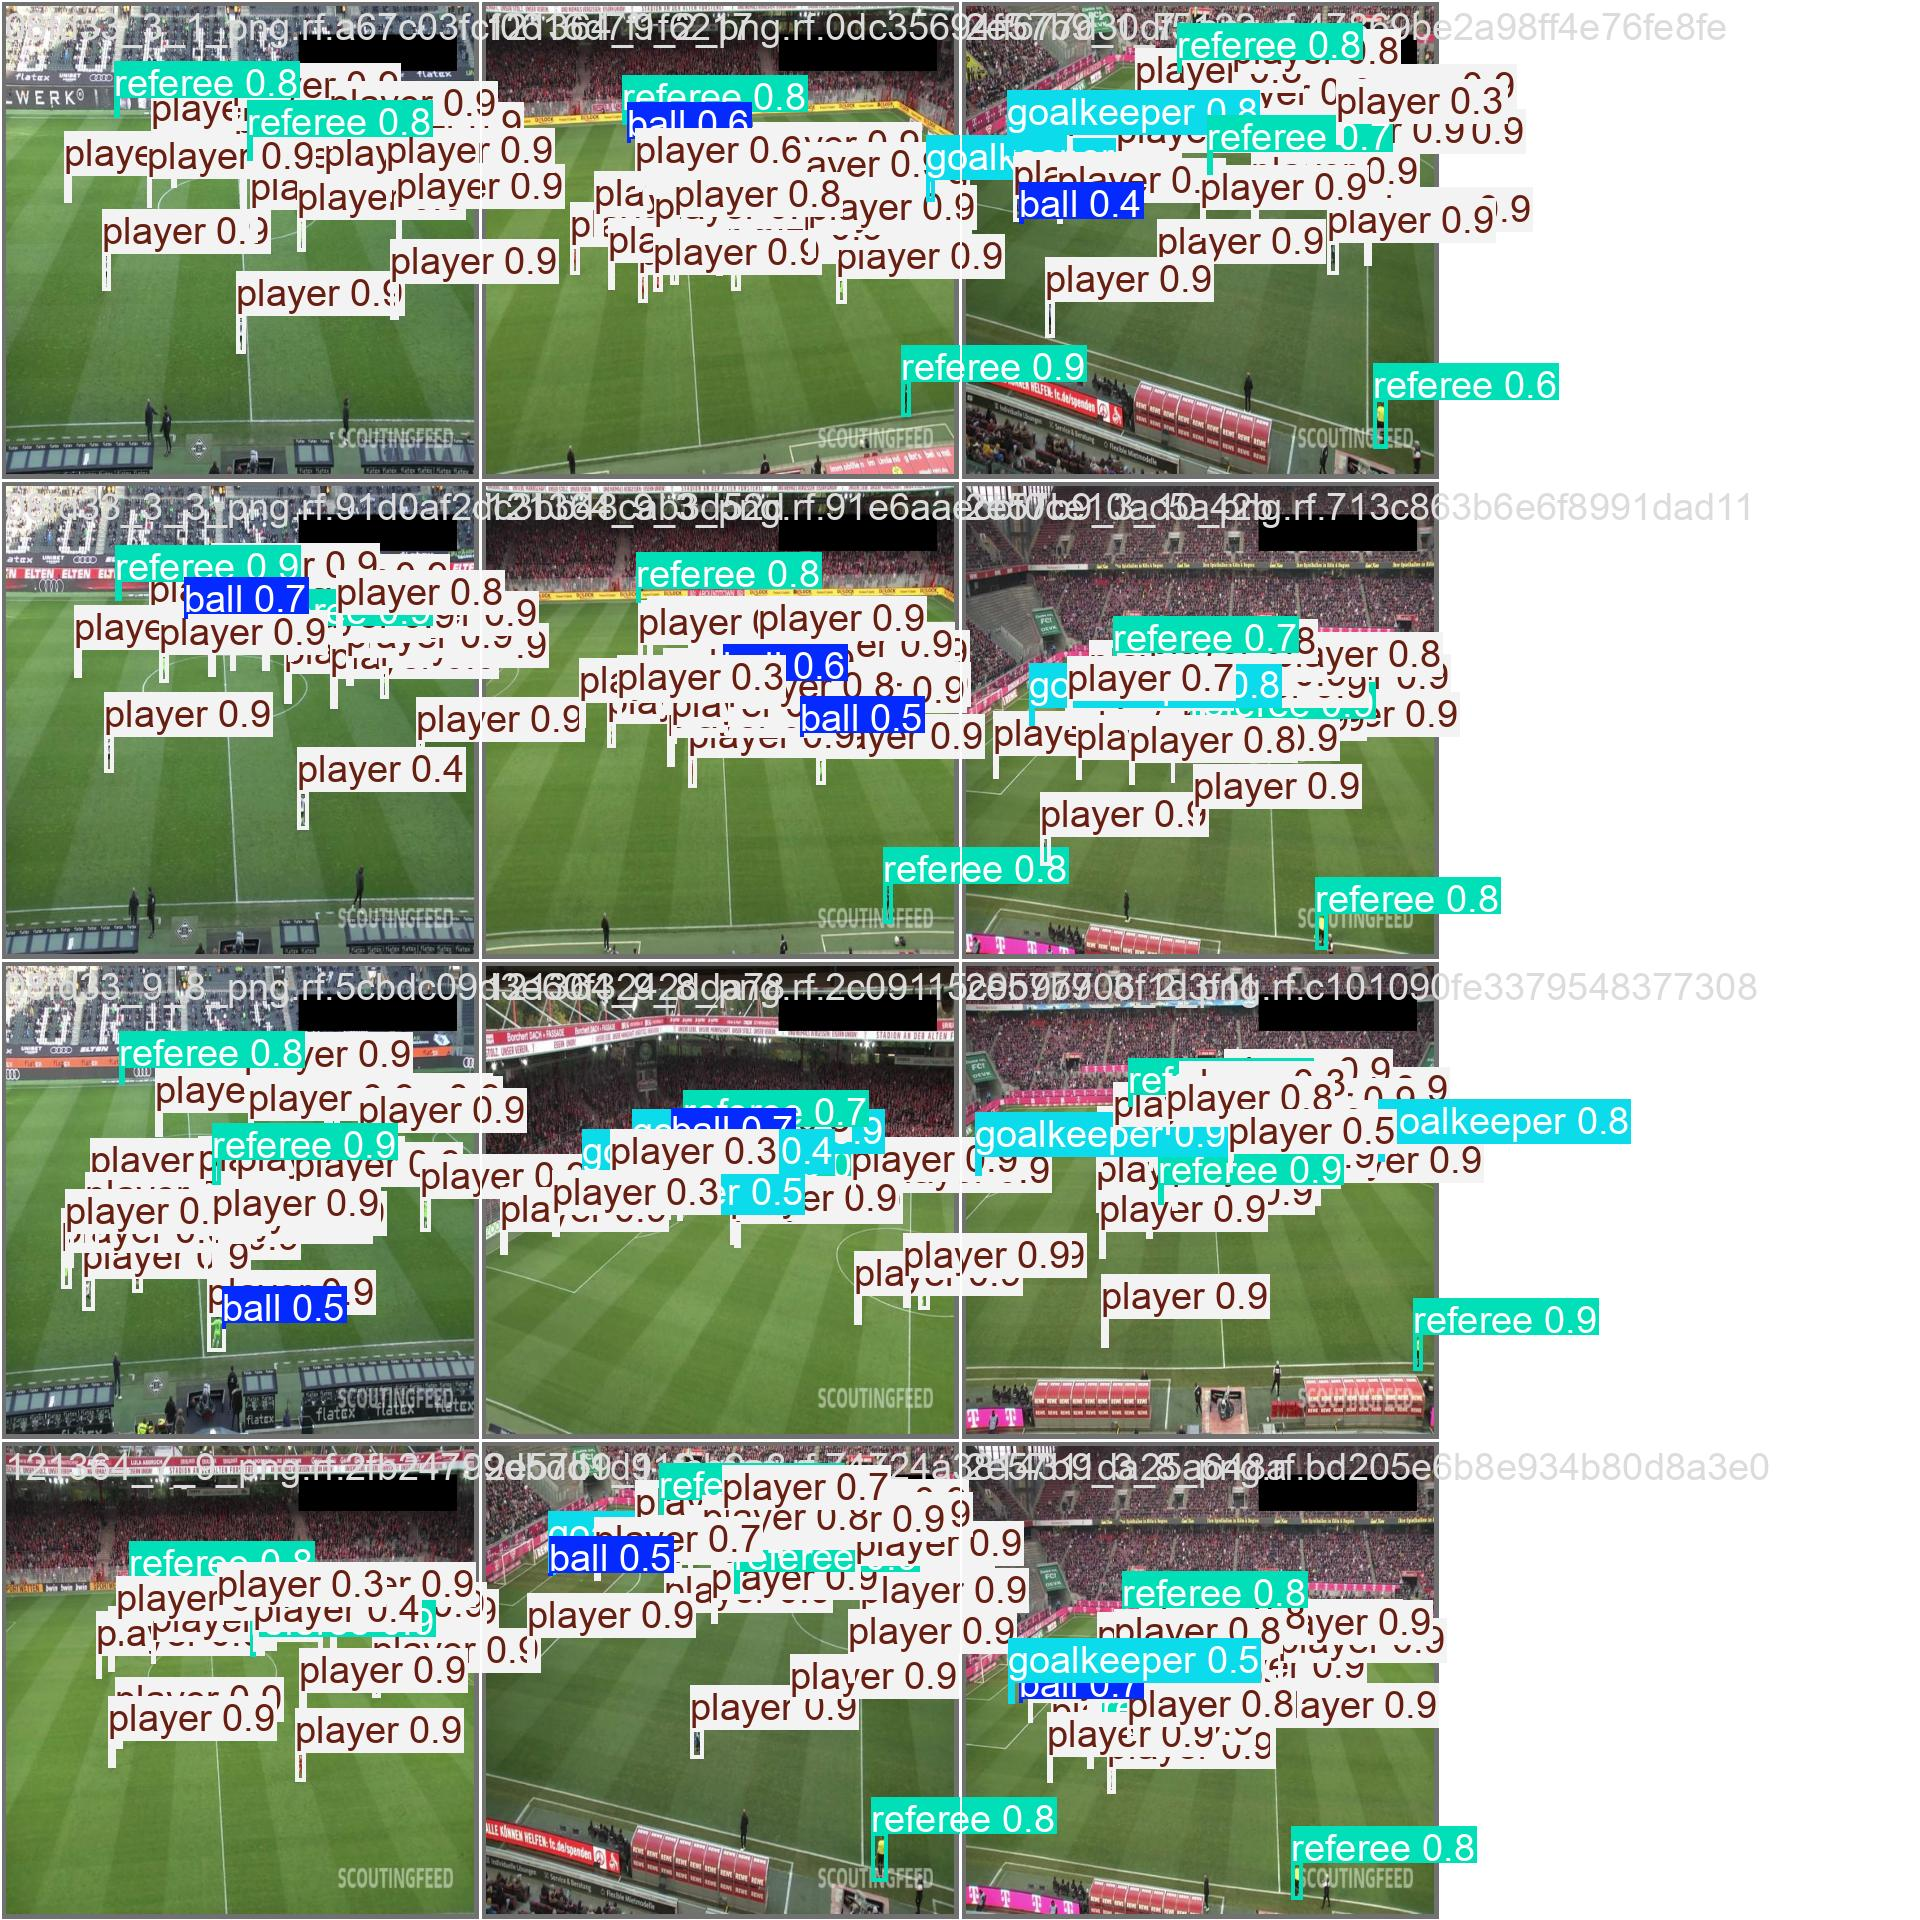

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

### **Validate Custom Model**

In [ ]:
# Change directory back to home directory
# Ensures consistent paths for saving results
os.chdir(HOME)

# Load the best checkpoint saved during training
# best.pt = weights from epoch with highest validation mAP
model = YOLO(f"{HOME}/runs/detect/train/weights/best.pt")

results = model.val(
    data=f"{dataset.location}/data.yaml", # points to validation images
    imgsz=1280  # same size used during training
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO26x summary (fused): 190 layers, 55,638,168 parameters, 0 gradients, 193.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1562.7±252.7 MB/s, size: 51.6 KB)
val: Scanning /content/football-players-detection-20/valid/labels.cache... 49 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 49/49 18.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.0s/it 7.8s
                   all         49       1174      0.949      0.817      0.903      0.627
                  ball         45         45       0.93      0.578      0.751      0.384
            goalkeeper         38         39      0.895      0.795      0.894      0.674
                player         49        973      0.988      0.972      0.993      0.782
               referee         49        117      0.982      0.921      0.976      0.667
Speed: 16.0ms preprocess,

### **Deploy Model on Roboflow**

In [ ]:
# project.version(dataset.version).deploy(model_type="yolo26", model_path=f"{HOME}/runs/detect/train/")

from google.colab import files

files.download(f"{HOME}/runs/detect/train/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### **Try Model On Sample Video**

In [ ]:
!pip install -q gdown supervision # Python library by Roboflow that makes it easier to work with computer vision model outputs

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 10.2 MB/s eta 0:00:00


In [ ]:
!gdown --fuzzy "https://drive.google.com/file/d/1BZ0rgfJXxVX1BVAX8Kyz1hFGxaHsJ1YX/view?usp=sharing" -O "FIFA_WorldCup_Chelsea_PSG.mp4"
!gdown --fuzzy "https://drive.google.com/file/d/1WFGR1pF5Uy5ee40YXaBs9b4T8hHu4w6p/view?usp=sharing" -O "object_detection_model.pt"

Downloading...
From: https://drive.google.com/uc?id=1BZ0rgfJXxVX1BVAX8Kyz1hFGxaHsJ1YX
To: /content/FIFA_WorldCup_Chelsea_PSG.mp4
100% 33.2M/33.2M [00:00<00:00, 77.9MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1WFGR1pF5Uy5ee40YXaBs9b4T8hHu4w6p
From (redirected): https://drive.google.com/uc?id=1WFGR1pF5Uy5ee40YXaBs9b4T8hHu4w6p&confirm=t&uuid=a1890515-e424-44c7-9f7a-4b03cd7bf5aa
To: /content/object_detection_model.pt
100% 118M/118M [00:01<00:00, 60.2MB/s]


In [ ]:
import os

# Force ONNX Runtime to only use GPU instead of fallback to CPU
os.environ["ONNXRUNTIME_EXECUTION_PROVIDERS"] = "[CUDAExecutionProvider]"

# Load model
MODEL = YOLO("/content/object_detection_model.pt")

In [ ]:
from tqdm import tqdm
import supervision as sv

# Video sample path
SOURCE_VIDEO_PATH = "/content/FIFA_WorldCup_Chelsea_PSG.mp4"
TARGET_VIDEO_PATH = "/content/FIFA_WorldCup_Chelsea_PSG_Output.mp4"

# Draws the bounding boxes around detected objects
box_annotator = sv.BoxAnnotator(
    color=sv.ColorPalette.from_hex(['#FF8C00', '#00BFFF', '#FF1493', '#FFD700']),
    thickness=2
)
# Draws the text labels (class name + confidence) on the boxes
label_annotator = sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(['#FF8C00', '#00BFFF', '#FF1493', '#FFD700']),
    text_color=sv.Color.from_hex('#000000')
)

video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH) # reads metadata from the input video (fps, resolution, total frames)
video_sink = sv.VideoSink(TARGET_VIDEO_PATH, video_info=video_info) # opens the output video file for writing, using the same metadata
frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH) # creates a lazy iterator that yields one frame at a time

with video_sink:
  for frame in tqdm(frame_generator, total=video_info.total_frames):
    result = MODEL(frame, conf=0.3)[0] # runs YOLO on the current frame, only keeping detections with 30%+ confidence
    detections = sv.Detections.from_ultralytics(result)

    labels = [
        f"{detections.data['class_name'][i]} {detections.confidence[i]:.2f}"
        for i in range(len(detections))
    ]

    # Annotate current frame, including bounding box and labels (class + confidence)
    annotated_frame = frame.copy()
    anotated_frame = box_annotator.annotate(annotated_frame, detections)
    annotated_frame = label_annotator.annotate(annotated_frame, detections, labels=labels)
    video_sink.write_frame(annotated_frame) # writes the annotated frame to the output video file


  0%|          | 0/354 [00:00<?, ?it/s]


0: 736x1280 1 ball, 20 players, 2 referees, 124.0ms
Speed: 13.7ms preprocess, 124.0ms inference, 35.2ms postprocess per image at shape (1, 3, 736, 1280)


  0%|          | 1/354 [00:02<16:48,  2.86s/it]


0: 736x1280 20 players, 2 referees, 32.8ms
Speed: 7.0ms preprocess, 32.8ms inference, 0.5ms postprocess per image at shape (1, 3, 736, 1280)

0: 736x1280 19 players, 2 referees, 32.6ms
Speed: 11.5ms preprocess, 32.6ms inference, 0.4ms postprocess per image at shape (1, 3, 736, 1280)


  1%|          | 3/354 [00:03<04:38,  1.26it/s]

...

 99%|█████████▉| 351/354 [00:26<00:00, 15.02it/s]


0: 736x1280 2 balls, 13 players, 32.9ms
Speed: 6.3ms preprocess, 32.9ms inference, 0.5ms postprocess per image at shape (1, 3, 736, 1280)

0: 736x1280 12 players, 33.2ms
Speed: 6.5ms preprocess, 33.2ms inference, 0.5ms postprocess per image at shape (1, 3, 736, 1280)


100%|█████████▉| 353/354 [00:26<00:00, 15.06it/s]


0: 736x1280 14 players, 33.5ms
Speed: 6.5ms preprocess, 33.5ms inference, 0.5ms postprocess per image at shape (1, 3, 736, 1280)


100%|██████████| 354/354 [00:26<00:00, 13.51it/s]
